In [18]:
##### Figure 2: grid-scale capital and labor, including AOA analysis

from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import rasterio
import rioxarray as rio
import string

In [13]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

# Import data
capital_modeled = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD.tif")
labor_modeled = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs.tif")

capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_relative_final_thinned.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_relative_final_thinned.csv")
raster_model = pd.read_parquet(f"{cd}/Data/Clean/Training_data/raster_predictor_matrix_relative.parquet")

fold_cap = pd.read_csv(f"{cd}/Data/Fold_assignments/capital_folds.csv")
fold_lab = pd.read_csv(f"{cd}/Data/Fold_assignments/labor_folds.csv")

imp_cap_df = pd.read_csv(f"{cd}/Results/RF_models_final/capital_rf_spatial_CV/feature_importance.csv")
imp_lab_df = pd.read_csv(f"{cd}/Results/RF_models_final/labor_rf_spatial_CV/feature_importance.csv")

ref_path = f"{cd}/Data/Clean/Production/total_production_tonnes_2020.tif"

country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo 
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [14]:
##### Add CV fold assignments to capital and labor model data
def wide_folds_to_fold_id(fold_df, id_col='country_ID'):
    fold_cols = [c for c in fold_df.columns if c.startswith('fold_')]
    fold_id = fold_df[fold_cols].values.argmax(axis=1) + 1
    out = fold_df[[id_col]].copy()
    out['fold_id'] = fold_id
    return out

fold_id_cap = wide_folds_to_fold_id(fold_cap)
fold_id_lab = wide_folds_to_fold_id(fold_lab)

capital_model['country_ID'] = capital_model['PROJ_ID'].astype(str).str[:3]
labor_model['country_ID'] = labor_model['PROJ_ID'].astype(str).str[:3]

capital_model = capital_model.merge(fold_id_cap, on='country_ID', how='left')
labor_model = labor_model.merge(fold_id_lab, on='country_ID', how='left')

##### Identify no data countries
country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

In [15]:
#### Predictor columns for each model

capital_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_USD_production_per_million_HA',
       'rtv_log_tonnes_production_per_million_HA',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_sheep_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_cereals_share_base_100_production_tonnes',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_vegetables_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_share_base_100_large_field',
       'rtv_log_share_base_100_with_nightlights']

labor_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_rest_of_crops_share_base_100_production_tonnes',
       'rtv_log_sugar_crops_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_pct_base_100_GDP_ag', 'rtv_log_share_base_100_large_field',
       'rtv_log_pct_base_100_cropland_irrigated']

#### Prep predictor matrices

X_train_lab_full = labor_model[labor_cols + ['fold_id']].dropna()
X_train_lab = X_train_lab_full[labor_cols]
fold_ids_lab = X_train_lab_full['fold_id'].values

X_train_cap_full = capital_model[capital_cols + ['fold_id']].dropna()
X_train_cap = X_train_cap_full[capital_cols]
fold_ids_cap = X_train_cap_full['fold_id'].values

X_pixel_raw_lab = raster_model[labor_cols]
X_pixel_raw_cap = raster_model[capital_cols]

valid_mask_lab = X_pixel_raw_lab.notna().all(axis=1)
valid_mask_cap = X_pixel_raw_cap.notna().all(axis=1)

scaler_lab = StandardScaler()
X_train_scaled_lab = scaler_lab.fit_transform(X_train_lab)
X_pixel_scaled_lab = scaler_lab.transform(X_pixel_raw_lab[valid_mask_lab])

scaler_cap = StandardScaler()
X_train_scaled_cap = scaler_cap.fit_transform(X_train_cap)
X_pixel_scaled_cap = scaler_cap.transform(X_pixel_raw_cap[valid_mask_cap])

##### Apply variable importance weighting (Meyer & Pebesma, 2021, Section 2.2)

imp_lab_map = imp_lab_df.set_index('feature')['permutation_mean'].to_dict()
imp_cap_map = imp_cap_df.set_index('feature')['permutation_mean'].to_dict()

importance_lab = np.array([imp_lab_map[c] for c in labor_cols])
importance_cap = np.array([imp_cap_map[c] for c in capital_cols])

X_train_scaled_lab = X_train_scaled_lab * importance_lab
X_pixel_scaled_lab = X_pixel_scaled_lab * importance_lab

X_train_scaled_cap = X_train_scaled_cap * importance_cap
X_pixel_scaled_cap = X_pixel_scaled_cap * importance_cap

#### Dissimilarity index + AOA threshold (Meyer & Pebesma, 2021)

def cross_fold_nn_distance(X_scaled, fold_ids):
    """Distance from each training point to its nearest neighbor among
    training points NOT in the same CV fold — needed for the AOA threshold."""
    dists = np.full(len(X_scaled), np.nan)
    fold_ids = np.asarray(fold_ids)
    for fold in np.unique(fold_ids):
        held_out_mask = fold_ids == fold
        pool_mask = ~held_out_mask
        nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
        nn.fit(X_scaled[pool_mask])
        d, _ = nn.kneighbors(X_scaled[held_out_mask])
        dists[held_out_mask] = d[:, 0]
    return dists

def compute_di_and_threshold(X_train_scaled, X_pixel_scaled, fold_ids):
    nn_train = NearestNeighbors(n_neighbors=2, n_jobs=-1)
    nn_train.fit(X_train_scaled)
    train_nn_dists, _ = nn_train.kneighbors(X_train_scaled)
    avg_train_nn_dist = train_nn_dists[:, 1].mean()

    nn_pixel = NearestNeighbors(n_neighbors=1, n_jobs=-1)
    nn_pixel.fit(X_train_scaled)
    pixel_nn_dists, _ = nn_pixel.kneighbors(X_pixel_scaled)
    DI = pixel_nn_dists[:, 0] / avg_train_nn_dist

    train_cross_fold_dists = cross_fold_nn_distance(X_train_scaled, fold_ids)
    train_di = train_cross_fold_dists / avg_train_nn_dist
    q25, q75 = np.percentile(train_di, [25, 75])
    threshold = q75 + 1.5 * (q75 - q25)

    return DI, threshold

DI_lab, aoa_threshold_lab = compute_di_and_threshold(X_train_scaled_lab, X_pixel_scaled_lab, fold_ids_lab)
DI_cap, aoa_threshold_cap = compute_di_and_threshold(X_train_scaled_cap, X_pixel_scaled_cap, fold_ids_cap)

#### Rasterize DI/AOA

ref_da = rio.open_rasterio(ref_path).squeeze()
height, width = ref_da.shape
transform = ref_da.rio.transform()

def values_to_dataarray(values, rows, cols, template, height, width):
    grid = np.full((height, width), np.nan, dtype=np.float32)
    grid[rows, cols] = values
    return template.copy(data=grid)

rows_lab, cols_lab = rasterio.transform.rowcol(
    transform,
    raster_model.loc[valid_mask_lab, 'x'].values,
    raster_model.loc[valid_mask_lab, 'y'].values,
)
rows_lab, cols_lab = np.array(rows_lab), np.array(cols_lab)

rows_cap, cols_cap = rasterio.transform.rowcol(
    transform,
    raster_model.loc[valid_mask_cap, 'x'].values,
    raster_model.loc[valid_mask_cap, 'y'].values,
)
rows_cap, cols_cap = np.array(rows_cap), np.array(cols_cap)

di_grid_labor = values_to_dataarray(DI_lab, rows_lab, cols_lab, ref_da, height, width)
aoa_grid_labor = values_to_dataarray(
    (DI_lab <= aoa_threshold_lab).astype(np.float32), rows_lab, cols_lab, ref_da, height, width
)

di_grid_capital = values_to_dataarray(DI_cap, rows_cap, cols_cap, ref_da, height, width)
aoa_grid_capital = values_to_dataarray(
    (DI_cap <= aoa_threshold_cap).astype(np.float32), rows_cap, cols_cap, ref_da, height, width
)

In [16]:
#### Align rasters to a shared projection/grid for plotting

crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
country_boundaries = country_boundaries.to_crs(crs)
no_data_color = "#e0e0e0"

di_grid_labor = di_grid_labor.rio.reproject(crs)
di_grid_capital = di_grid_capital.rio.reproject(crs)
di_grid_capital = di_grid_capital.where(di_grid_capital > 0)
di_grid_labor = di_grid_labor.where(di_grid_labor > 0)

aoa_grid_labor = aoa_grid_labor.rio.reproject(crs).rio.reproject_match(di_grid_capital)
aoa_grid_capital = aoa_grid_capital.rio.reproject(crs).rio.reproject_match(di_grid_capital)
aoa_grid_capital = aoa_grid_capital.where(di_grid_capital.notnull())
aoa_grid_labor = aoa_grid_labor.where(di_grid_labor.notnull())

aoa_plot_capital = aoa_grid_capital.squeeze()
aoa_plot_labor = aoa_grid_labor.squeeze()

capital_modeled = capital_modeled.rio.reproject(crs).rio.reproject_match(di_grid_capital)
labor_modeled = labor_modeled.rio.reproject(crs).rio.reproject_match(di_grid_capital)
capital_modeled = capital_modeled.where(di_grid_capital.notnull()).squeeze()
labor_modeled = labor_modeled.where(di_grid_labor.notnull()).squeeze()

production_for_aoa = rio.open_rasterio(ref_path)
production_for_aoa = production_for_aoa.rio.reproject(crs).rio.reproject_match(di_grid_capital)
production_for_aoa = production_for_aoa.where(production_for_aoa > 0).squeeze()

prod_capital = production_for_aoa.where(aoa_plot_capital.notnull())
prod_labor = production_for_aoa.where(aoa_plot_labor.notnull())

minx, miny, maxx, maxy = country_boundaries.total_bounds

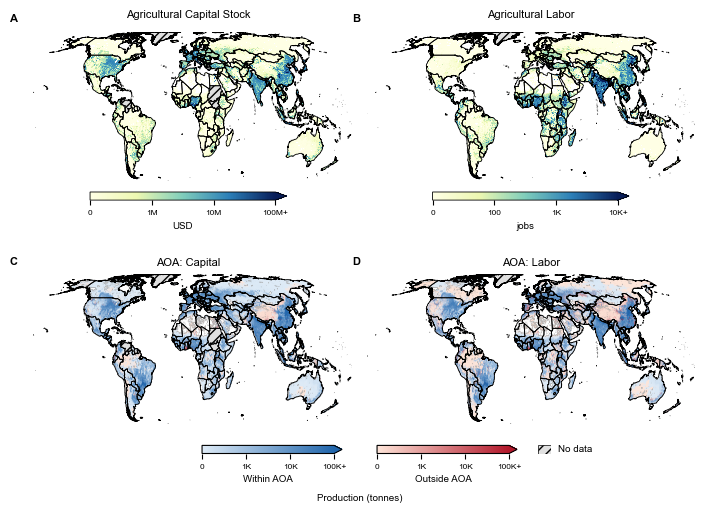

In [ ]:
##### FIGURE 2: Capital, labor, and AOA

# set formating
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']

TITLE_FS = 8   # panel titles
LABEL_FS = 7   # axis/colorbar labels
TICK_FS = 6    # tick labels
PANEL_LETTER_FS = 8

def draw_total_map(ax, value_plot, has_data_col, title, bounds):
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        "white_ylgnbu",
        ["#ffffe5", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
    )
    custom_cmap.set_over("#081d58")
    custom_cmap.set_bad(color='none')

    country_boundaries[country_boundaries[has_data_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="////", zorder=1
    )
    country_boundaries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2)

    positions = np.linspace(0, 1, len(bounds))
    def forward(x): return np.interp(x, bounds, positions)
    def inverse(x): return np.interp(x, positions, bounds)
    norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

    im = value_plot.plot(ax=ax, cmap=custom_cmap, norm=norm,
                          add_colorbar=False, add_labels=False, zorder=0)
    ax.set_axis_off()
    ax.set_title(title, fontsize=TITLE_FS, pad=10)
    return im

def add_map_legend(fig, ax, im, bounds, labels, cbar_label):
    pos = ax.get_position()
    cbar_width = pos.width * 0.6
    cbar_x0 = pos.x0 + (pos.width - cbar_width) / 2
    cbar_y0 = pos.y0 - 0.035
    cbar_height = 0.015

    cax = fig.add_axes([cbar_x0, cbar_y0, cbar_width, cbar_height])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='max', extendfrac=0.06)
    cbar.set_label(cbar_label, fontsize=LABEL_FS, labelpad=4)
    cbar.ax.tick_params(labelsize=TICK_FS)
    cbar.set_ticks(bounds)
    cbar.set_ticklabels(labels)
    cbar.outline.set_linewidth(0.6)

within_cmap = mcolors.LinearSegmentedColormap.from_list("light_to_dark_blue", ["#deebf7", "#2166ac"])
outside_cmap = mcolors.LinearSegmentedColormap.from_list("light_to_dark_red", ["#fee5d9", "#b2182b"])

prod_bounds = [0, 1_000, 10_000, 100_000]
prod_labels = ['0', '1K', '10K', '100K+']
prod_positions = np.linspace(0, 1, len(prod_bounds))

def _prod_forward(x): return np.interp(x, prod_bounds, prod_positions)
def _prod_inverse(x): return np.interp(x, prod_positions, prod_bounds)
prod_norm = mcolors.FuncNorm((_prod_forward, _prod_inverse), vmin=prod_bounds[0], vmax=prod_bounds[-1])

def build_aoa_production_rgba(aoa_da, prod_da):
    aoa = aoa_da.values
    prod = np.clip(prod_da.values, prod_bounds[0], prod_bounds[-1])

    h, w = aoa.shape
    rgba = np.zeros((h, w, 4), dtype=float)

    valid = np.isfinite(aoa) & np.isfinite(prod)
    within = valid & (aoa == 1)
    outside = valid & (aoa == 0)

    rgba[within] = within_cmap(prod_norm(prod[within]))
    rgba[outside] = outside_cmap(prod_norm(prod[outside]))
    return rgba

capital_map_bounds = [0, 1_000_000, 10_000_000, 100_000_000]
capital_map_labels = ['0', '1M', '10M', '100M+']

labor_map_bounds = [0, 100, 1_000, 10_000]
labor_map_labels = ['0', '100', '1K', '10K+']

# ================= BUILD FIGURE =================
fig, axes = plt.subplots(2, 2, figsize=(7, 5.4), sharex=True, sharey=True)

im_capital_total = draw_total_map(axes[0, 0], capital_modeled, "has_capital_data",
                                    "Agricultural Capital Stock", capital_map_bounds)
im_labor_total = draw_total_map(axes[0, 1], labor_modeled, "has_labor_data",
                                  "Agricultural Labor", labor_map_bounds)

rgba_capital = build_aoa_production_rgba(aoa_plot_capital, prod_capital)
rgba_labor = build_aoa_production_rgba(aoa_plot_labor, prod_labor)

raster_left, raster_bottom, raster_right, raster_top = aoa_plot_capital.rio.bounds()

aoa_panels = [
    (rgba_capital, "has_capital_data", "AOA: Capital", axes[1, 0]),
    (rgba_labor,   "has_labor_data",   "AOA: Labor",   axes[1, 1]),
]

for rgba_img, data_flag_col, title, ax in aoa_panels:
    country_boundaries[country_boundaries[data_flag_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
    )
    country_boundaries.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2)
    ax.imshow(
        rgba_img,
        extent=[raster_left, raster_right, raster_bottom, raster_top],
        origin="upper",
        zorder=0,
    )
    ax.set_axis_off()
    ax.set_title(title, fontsize=TITLE_FS, pad=6)

axes[0, 0].set_xlim(minx, maxx)
axes[0, 0].set_ylim(miny, maxy)

plt.tight_layout()
fig.subplots_adjust(hspace=0.18, top=0.95, bottom=0.12)
fig.canvas.draw()

# ---- Panel labels ----
for ax, letter in zip(axes.flat, string.ascii_uppercase):
    ax.text(-0.02, 1.05, letter, transform=ax.transAxes,
            fontsize=PANEL_LETTER_FS, fontweight='bold', va='bottom', ha='right')

add_map_legend(fig, axes[0, 0], im_capital_total, bounds=capital_map_bounds, labels=capital_map_labels, cbar_label="USD")
add_map_legend(fig, axes[0, 1], im_labor_total, bounds=labor_map_bounds, labels=labor_map_labels, cbar_label="jobs")

sm_within = plt.cm.ScalarMappable(cmap=within_cmap, norm=prod_norm)
sm_outside = plt.cm.ScalarMappable(cmap=outside_cmap, norm=prod_norm)

row2_pos = axes[1, 0].get_position()
row2_right_pos = axes[1, 1].get_position()

cbar_y0 = row2_pos.y0 - 0.055
cbar_height = 0.015
cbar_width = 0.20

center_x = (row2_pos.x1 + row2_right_pos.x0) / 2
gap = 0.05
cbar_ax_within = fig.add_axes([center_x - cbar_width - gap / 2, cbar_y0, cbar_width, cbar_height])
cbar_ax_outside = fig.add_axes([center_x + gap / 2, cbar_y0, cbar_width, cbar_height])

cbar_within = fig.colorbar(sm_within, cax=cbar_ax_within, orientation="horizontal",
                            extend='max', extendfrac=0.06)
cbar_outside = fig.colorbar(sm_outside, cax=cbar_ax_outside, orientation="horizontal",
                             extend='max', extendfrac=0.06)

for cbar, label in [(cbar_within, "Within AOA"), (cbar_outside, "Outside AOA")]:
    cbar.set_ticks(prod_bounds)
    cbar.set_ticklabels(prod_labels)
    cbar.ax.tick_params(labelsize=TICK_FS)
    cbar.set_label(label, fontsize=LABEL_FS, labelpad=4)

fig.text(center_x, cbar_y0 - 0.075, "Production (tonnes)",
          fontsize=LABEL_FS, ha="center", va="top")

swatch_size = 0.018
legend_ax = fig.add_axes([center_x + cbar_width + gap / 2 + 0.03, cbar_y0, swatch_size, cbar_height])
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1, facecolor=no_data_color, edgecolor="black", linewidth=0.5, hatch="///"
))
legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1)
legend_ax.axis("off")
fig.text(center_x + cbar_width + gap / 2 + 0.03 + swatch_size + 0.01, cbar_y0 + cbar_height / 2,
          "No data", fontsize=LABEL_FS, va="center", ha="left")

plt.show()

fig.savefig(f"{fd}/FIG_2_capital_labor_AOA.tiff", dpi=300, bbox_inches='tight',
            facecolor='white')